In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120 # Resolusi tinggi

df_summary = pd.read_csv('summary_simulation_results.csv')
df_items = pd.read_csv('item_level_logs.csv')

best_scenario_id = df_summary.iloc[0]['Skenario']
print(f"Skenario Terbaik yang akan dianalisis: {best_scenario_id}")

df_scenario = pd.read_excel('scenario_level_logs.xlsx', sheet_name=best_scenario_id[:31])

df_best_items = df_items[df_items['scenario_id'] == best_scenario_id].copy()

df_merged_items = pd.merge(
    df_best_items, 
    df_scenario[['student_id', 'ability_category', 'true_ability']], 
    on='student_id', 
    how='left'
)

Skenario Terbaik yang akan dianalisis: SL3-TL2-ST3


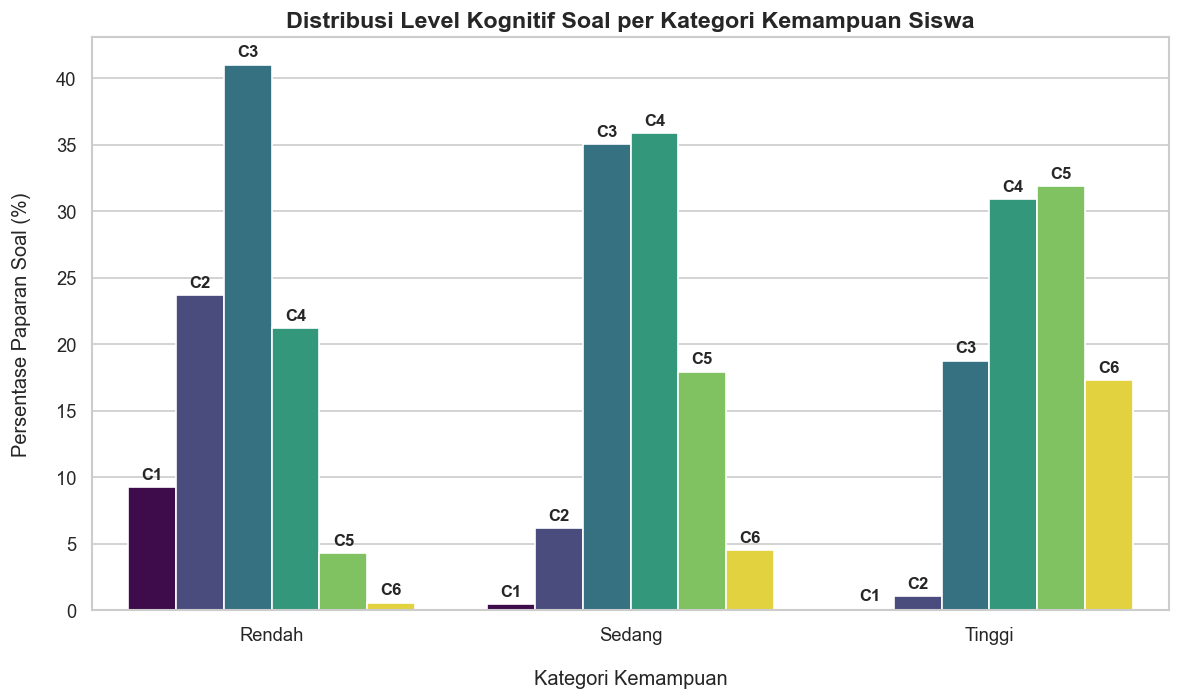

In [4]:
cog_distribution = df_merged_items.groupby(['ability_category', 'cognitive_level']).size().reset_index(name='jumlah_soal')
total_per_category = df_merged_items.groupby('ability_category').size().reset_index(name='total')
cog_distribution = pd.merge(cog_distribution, total_per_category, on='ability_category')
cog_distribution['persentase'] = (cog_distribution['jumlah_soal'] / cog_distribution['total']) * 100

plt.figure(figsize=(10, 6))
order_cat = ['Rendah', 'Sedang', 'Tinggi']

ax = sns.barplot(
    data=cog_distribution, 
    x='ability_category', 
    y='persentase', 
    hue='cognitive_level', 
    order=order_cat,
    palette='viridis'
)

plt.title('Distribusi Level Kognitif Soal per Kategori Kemampuan Siswa', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Kemampuan', fontsize=12, labelpad=15)
plt.ylabel('Persentase Paparan Soal (%)', fontsize=12, labelpad=15)

ax.get_legend().remove()

level_labels = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6']

for i, container in enumerate(ax.containers):
    ax.bar_label(container, labels=[level_labels[i]] * len(container), padding=3, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


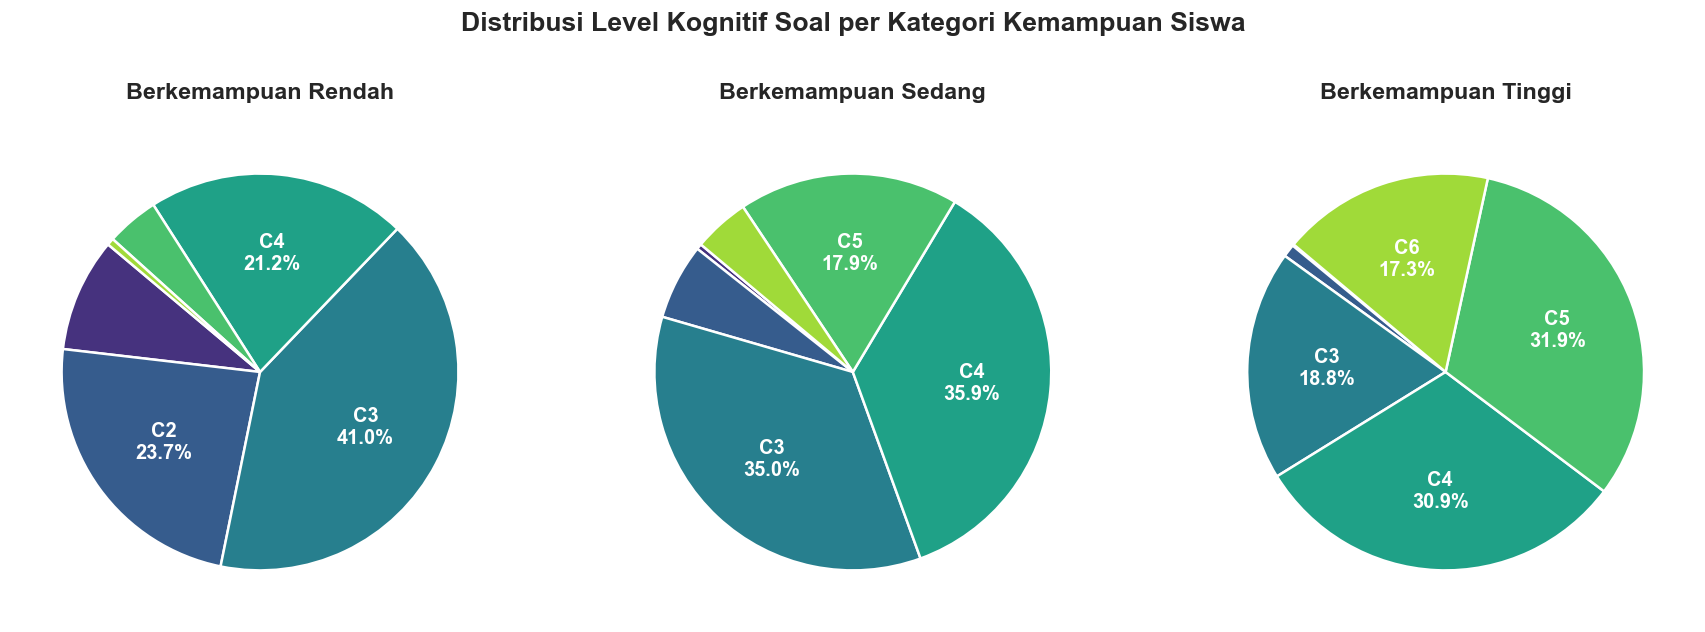

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

fig.suptitle('Distribusi Level Kognitif Soal per Kategori Kemampuan Siswa', 
            fontsize=16, fontweight='bold', y=1.05)

order_cat = ['Rendah', 'Sedang', 'Tinggi']
base_colors = sns.color_palette('viridis', 6)

for i, cat in enumerate(order_cat):
    data_cat = cog_distribution[cog_distribution['ability_category'] == cat].sort_values('cognitive_level')
    
    pie_colors = [base_colors[int(lvl)-1] for lvl in data_cat['cognitive_level']]
    
    wedges, texts, autotexts = axes[i].pie(
        data_cat['persentase'], 
        autopct='%1.1f%%',  
        startangle=140,
        colors=pie_colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        textprops={'color': 'white', 'fontsize': 12, 'fontweight': 'bold'} 
    )
    
    for j, autotext in enumerate(autotexts):
        pct_val = data_cat['persentase'].iloc[j]
        
        if pct_val > 10:
            lvl = int(data_cat['cognitive_level'].iloc[j])
            autotext.set_text(f"C{lvl}\n{pct_val:.1f}%")
        else:
            autotext.set_text('')
    
    axes[i].set_title(f'Berkemampuan {cat}', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

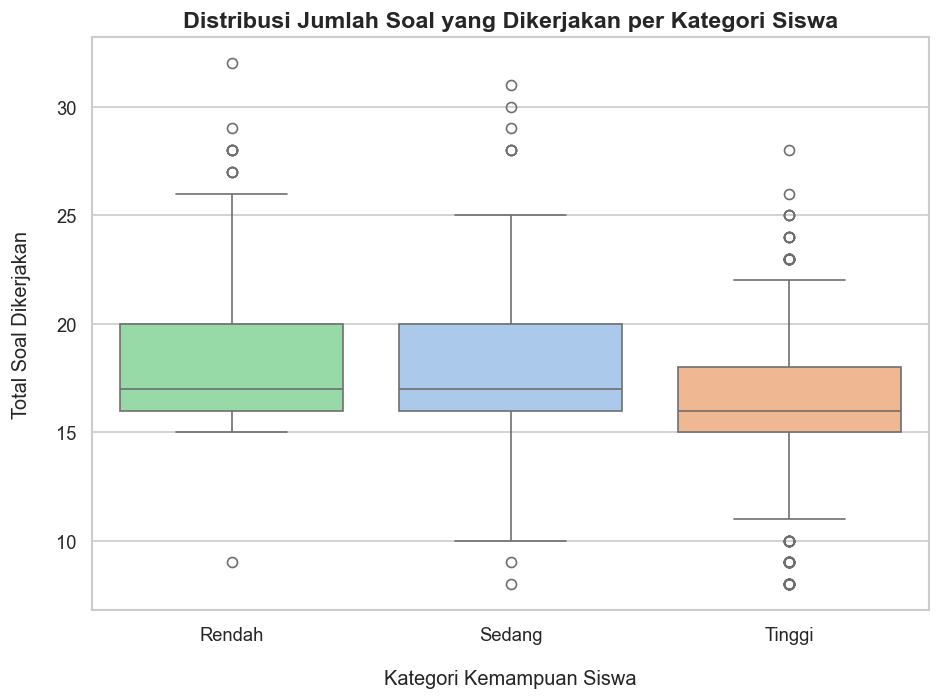

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_scenario, 
    x='ability_category', 
    y='total_items', 
    order=order_cat, 
    hue='ability_category', 
    palette='pastel', 
    legend=False            
)

plt.title('Distribusi Jumlah Soal yang Dikerjakan per Kategori Siswa', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Kemampuan Siswa', fontsize=12, labelpad=15)
plt.ylabel('Total Soal Dikerjakan', fontsize=12, labelpad=15)
plt.tight_layout()
plt.show()

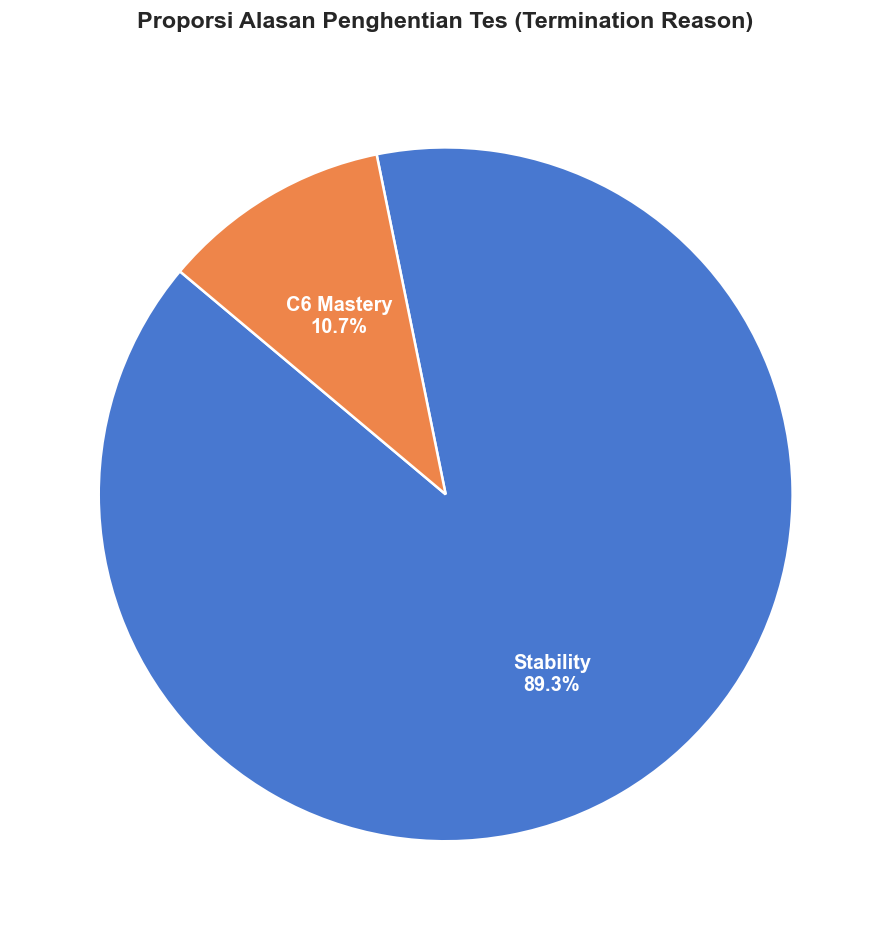

In [14]:
term_reason = df_scenario['termination_reason'].value_counts()
total_reasons = term_reason.sum()

palette = sns.color_palette("muted") 

plt.figure(figsize=(8, 8))

wedges, texts, autotexts = plt.pie(
    term_reason, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=palette,  
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'color': 'white', 'fontsize': 12, 'fontweight': 'bold'} 
)

for i, autotext in enumerate(autotexts):
    count = term_reason.iloc[i]
    pct_val = (count / total_reasons) * 100

    if pct_val > 8:
        reason = term_reason.index[i]
        autotext.set_text(f"{reason}\n{pct_val:.1f}%")
    else:
        autotext.set_text('')

plt.title('Proporsi Alasan Penghentian Tes (Termination Reason)', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

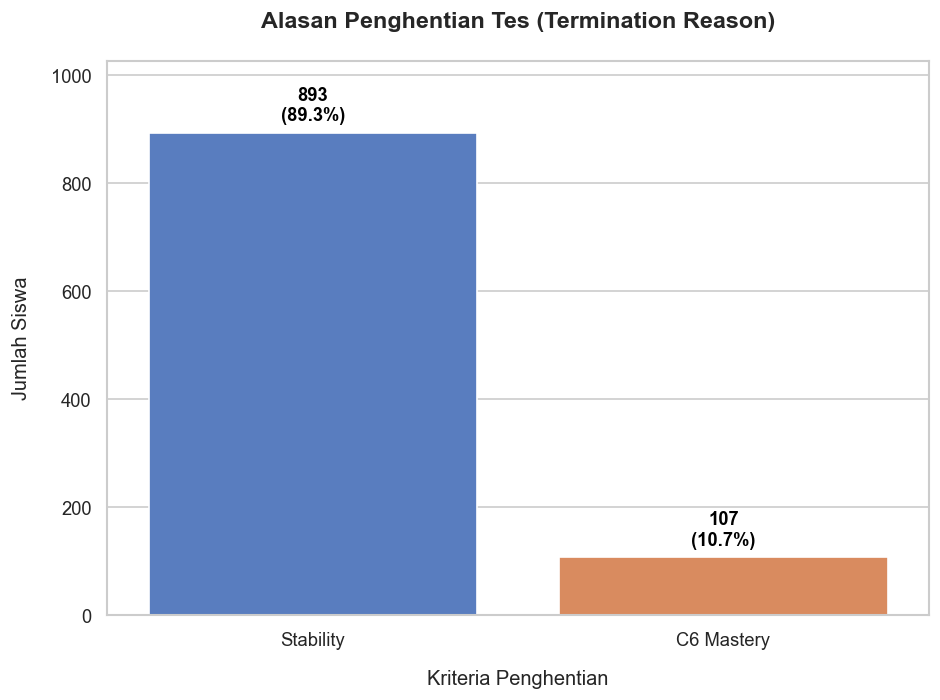

In [15]:
term_counts = df_scenario['termination_reason'].value_counts().reset_index()
term_counts.columns = ['reason', 'count']
total_students = term_counts['count'].sum()

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=term_counts, 
    x='reason', 
    y='count', 
    hue='reason',
    palette='muted', 
    legend=False
)

plt.title('Alasan Penghentian Tes (Termination Reason)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Kriteria Penghentian', fontsize=12, labelpad=12)
plt.ylabel('Jumlah Siswa', fontsize=12, labelpad=12)

for container in ax.containers:
    labels = []
    for bar in container:
        height = bar.get_height()
        if height > 0: 
            pct = (height / total_students) * 100
            labels.append(f"{int(height)}\n({pct:.1f}%)")
        else:
            labels.append("")

    ax.bar_label(container, labels=labels, padding=5, fontsize=11, fontweight='bold', color='black')

plt.ylim(0, term_counts['count'].max() * 1.15)

plt.tight_layout()
plt.show()

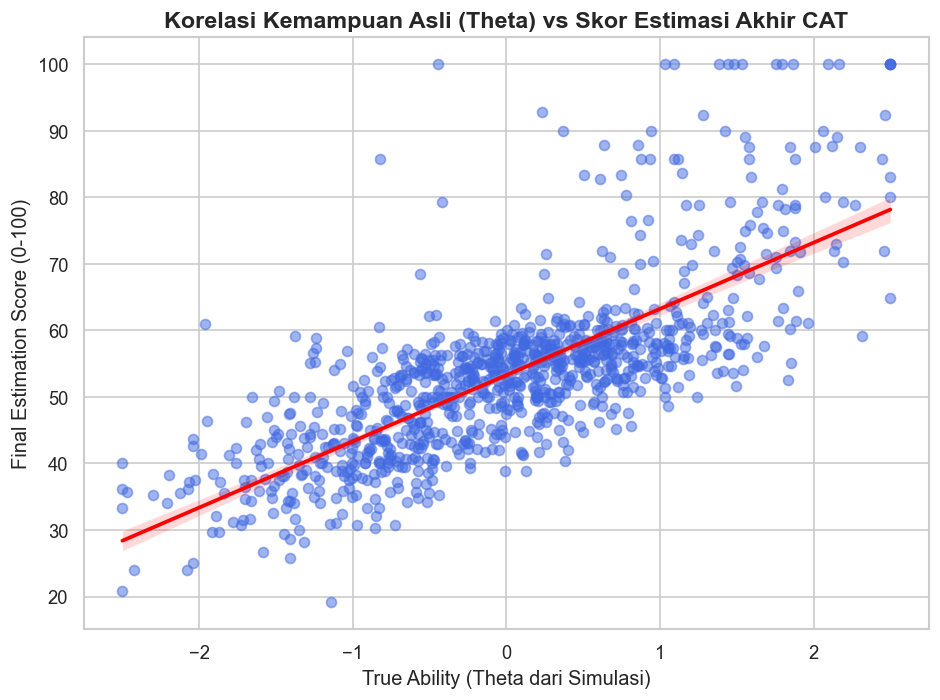

In [16]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df_scenario, x='true_ability', y='final_estimation_score', 
            scatter_kws={'alpha':0.5, 'color':'royalblue'}, line_kws={'color':'red'})
plt.title('Korelasi Kemampuan Asli (Theta) vs Skor Estimasi Akhir CAT', fontsize=14, fontweight='bold')
plt.xlabel('True Ability (Theta dari Simulasi)', fontsize=12)
plt.ylabel('Final Estimation Score (0-100)', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
pearson_val = df_summary.iloc[0]['Pearson']
spearman_val = df_summary.iloc[0]['Spearman']
print(f"Nilai Correlation adalah {spearman_val:.3f}. Semakin mendekati 1, semakin akurat tes mengukur siswa.")


Nilai Correlation adalah 0.764. Semakin mendekati 1, semakin akurat tes mengukur siswa.


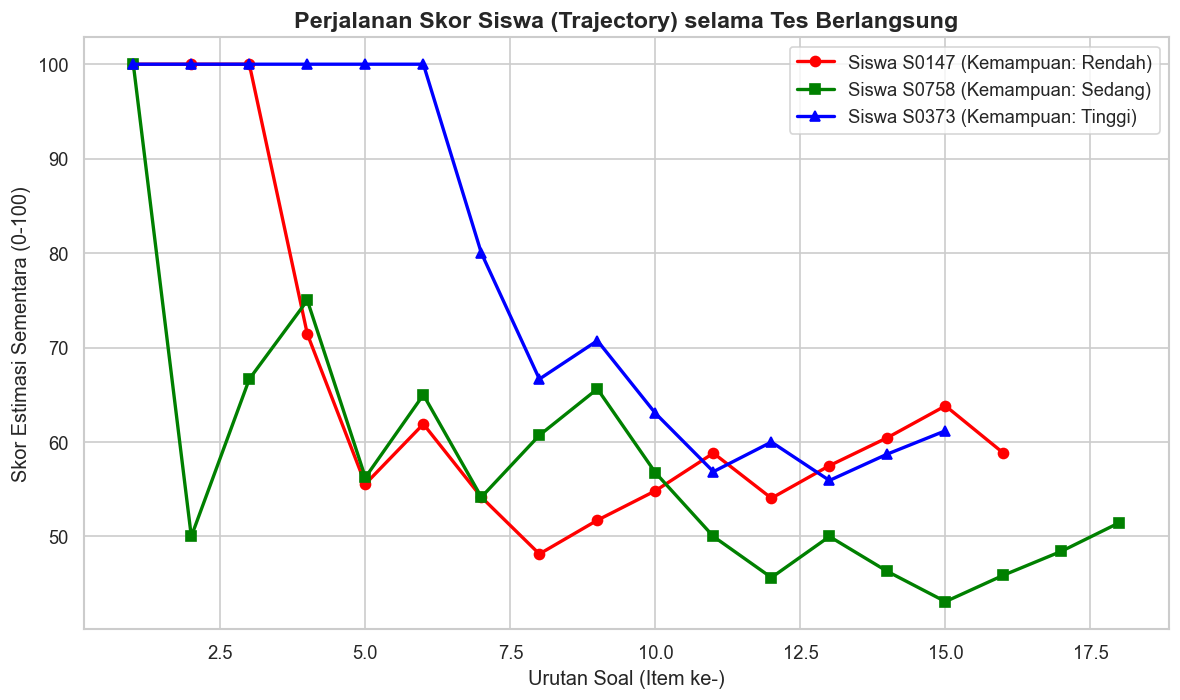

In [ ]:
np.random.seed(42)
sample_students = df_scenario.groupby('ability_category').sample(n=1, random_state=42).reset_index(drop=True)

plt.figure(figsize=(10, 6))
markers = ['o', 's', '^']
colors = ['red', 'green', 'blue']

for idx, row in sample_students.iterrows():
    student_id = row['student_id']
    cat = row['ability_category']
    
    hist_student = df_best_items[df_best_items['student_id'] == student_id].copy()
    hist_student['item_order'] = range(1, len(hist_student) + 1)
    
    plt.plot(hist_student['item_order'], hist_student['estimation_score_after_item'], 
             marker=markers[idx], color=colors[idx], linewidth=2, 
             label=f'Siswa {student_id} (Kemampuan: {cat})')

plt.title('Perjalanan Skor Siswa (Trajectory) selama Tes Berlangsung', fontsize=14, fontweight='bold')
plt.xlabel('Urutan Soal (Item ke-)', fontsize=12)
plt.ylabel('Skor Estimasi Sementara (0-100)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


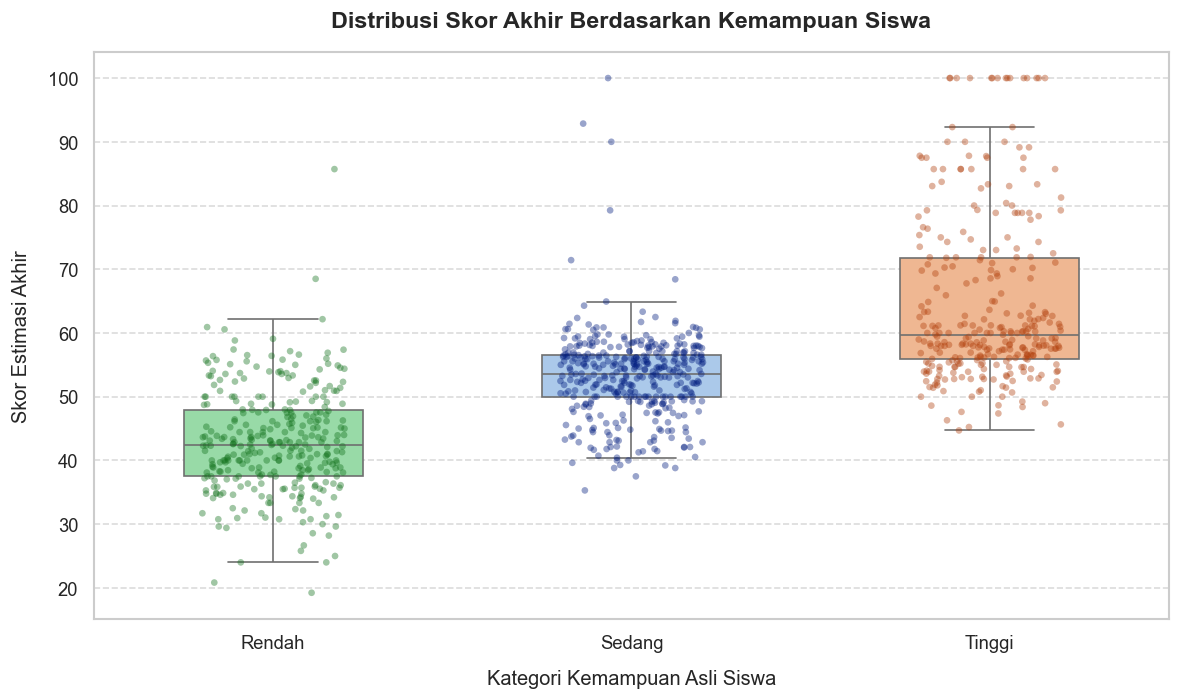

In [26]:
plt.figure(figsize=(10, 6))

order_cat = ['Rendah', 'Sedang', 'Tinggi']

sns.boxplot(
    data=df_scenario, 
    x='ability_category', 
    y='final_estimation_score', 
    order=order_cat,
    hue='ability_category',  
    palette='pastel',       
    legend=False,
    width=0.5,
    showfliers=False         
)

sns.stripplot(
    data=df_scenario, 
    x='ability_category', 
    y='final_estimation_score', 
    order=order_cat,
    hue='ability_category', 
    palette='dark',         
    legend=False,
    alpha=0.4,             
    jitter=0.2,            
    size=4
)

plt.title(f'Distribusi Skor Akhir Berdasarkan Kemampuan Siswa', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kategori Kemampuan Asli Siswa', fontsize=12, labelpad=10)
plt.ylabel('Skor Estimasi Akhir', fontsize=12, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()